# 학생 성적 데이터 전처리·EDA·회귀 모델링

**작성**: 연구자 1

**연구 계획**  
- `train.csv`(학생 성적 데이터)를 기반으로 전처리합니다.  
- 탐색적 데이터 분석(EDA)를 수행하고  
- `scikit-learn` 회귀 모델링을 수행합니다.  
- RMSE로 평가한 최종 모델을 `model.pkl`로 저장합니다.  

> 이후 이 과정을 `train.py` 스크립트로 정리하여 Docker 이미지로 자동화합니다.

**사전에 공유된 테이터 컬럼 설명**
| 변수명 | 설명 |
|---|---|
| Hours Studied | 공부에 소요한 총 시간 |
| Previous Scores | 이전 시험 점수 |
| Extracurricular Activities | 과외 활동 참여 여부 (Yes/No) |
| Sleep Hours | 하루 평균 수면 시간 |
| Sample Question Papers Practiced | 연습한 모의고사 수 |
| Performance Index | **목표변수** (10~100, 높을수록 우수) |

## 0. 패키지 임포트 및 버전 확인

In [ ]:
import platform

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Record environment so researcher 2 can reproduce with identical versions
print(f"python       : {platform.python_version()}")
print(f"numpy        : {np.__version__}")
print(f"pandas       : {pd.__version__}")
print(f"scikit-learn : {sklearn.__version__}")
print(f"joblib       : {joblib.__version__}")

python       : 3.11.15
numpy        : 1.26.4
pandas       : 2.2.2
scikit-learn : 1.5.1
joblib       : 1.4.2


## 1. 데이터 로드 및 전역 참조 값 설정

사전에 공유 받은 mission15_train.csv 에서 데이터를 로드합니다.  
목표 변수는 `Performance Index` 입니다.  
과외 활동 참여 여부는 Yes or No 라 이후 이진 인코딩 처리를 위해 미리 선언합니다.  
전역 참조 랜덤 시드는 42 로 설정합니다.

In [2]:
TRAIN_CSV_PATH = "data/mission15_train.csv"
TARGET_COLUMN = "Performance Index"
CATEGORICAL_COLUMN = "Extracurricular Activities"
RANDOM_SEED = 42

try:
    train_df = pd.read_csv(TRAIN_CSV_PATH)
except FileNotFoundError:
    raise SystemExit(f"Training data not found: {TRAIN_CSV_PATH}")

print(f"shape: {train_df.shape}")
train_df.head()

shape: (7000, 6)


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,6,73,No,7,2,58.0
1,1,89,Yes,7,2,64.0
2,3,97,Yes,8,0,75.0
3,8,70,No,5,5,59.0
4,7,94,Yes,7,4,86.0


## 2. 데이터 품질 점검

전처리 전에 결측치, 중복, 자료형, 값 범위를 확인합니다.

In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     7000 non-null   int64  
 1   Previous Scores                   7000 non-null   int64  
 2   Extracurricular Activities        7000 non-null   object 
 3   Sleep Hours                       7000 non-null   int64  
 4   Sample Question Papers Practiced  7000 non-null   int64  
 5   Performance Index                 7000 non-null   float64
dtypes: float64(1), int64(4), object(1)
memory usage: 328.3+ KB


In [4]:
summary = pd.DataFrame({
    "dtype": train_df.dtypes,
    "n_missing": train_df.isna().sum(),
    "n_unique": train_df.nunique(),
})
print(summary)
print(f"\nduplicated rows: {train_df.duplicated().sum()}")

                                    dtype  n_missing  n_unique
Hours Studied                       int64          0         9
Previous Scores                     int64          0        60
Extracurricular Activities         object          0         2
Sleep Hours                         int64          0         6
Sample Question Papers Practiced    int64          0        10
Performance Index                 float64          0        91

duplicated rows: 64


In [5]:
train_df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,4.950000,69.429714,6.530571,4.607429,55.095143
std,2.590621,17.289197,1.696144,2.863550,19.151574
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,70.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


### 품질 점검 결과 및 전처리 방침

- **결측치 없음** → 결측치에 대한 별도 처리가 불필요합니다.
- **중복 행 존재 가능** → 동일 관측이 학습을 왜곡하지 않도록 제거합니다.
- `Extracurricular Activities`는 Yes/No 문자열 → **1/0 이진 인코딩**
- 나머지 변수는 모두 수치형이며 값 범위가 상이 →  
    모델 파이프라인에서 **표준화(StandardScaler)** 처리하겠습니다.

In [6]:
def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    """Encode Yes/No to 1/0 and drop duplicated rows."""
    out = df.drop_duplicates().copy()
    out[CATEGORICAL_COLUMN] = (
        out[CATEGORICAL_COLUMN].map({"Yes": 1, "No": 0}).astype("int64")
    )
    if out[CATEGORICAL_COLUMN].isna().any():
        raise ValueError(f"Unexpected value in '{CATEGORICAL_COLUMN}'")
    return out


clean_df = preprocess(train_df)
print(f"before: {train_df.shape}, after: {clean_df.shape}")
clean_df.head()

before: (7000, 6), after: (6936, 6)


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,6,73,0,7,2,58.0
1,1,89,1,7,2,64.0
2,3,97,1,8,0,75.0
3,8,70,0,5,5,59.0
4,7,94,1,7,4,86.0


## 3. 탐색적 데이터 분석 (EDA)

### 3-1. 목표변수 분포

목표 변수인 `Performance Index` 의 0 ~ 100 범위 값을  
30개의 범위로 나누어 막대그래프로 표기합니다.  
또한 평균, 편차, 최소 ~ 구간 ~ 최대 값을 표기합니다.

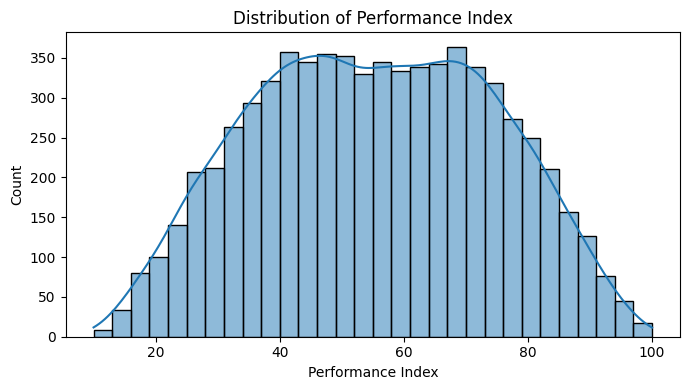

count    6936.000000
mean       55.091407
std        19.142497
min        10.000000
25%        40.000000
50%        55.000000
75%        70.000000
max       100.000000
Name: Performance Index, dtype: float64


In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(clean_df[TARGET_COLUMN], bins=30, kde=True, ax=ax)
ax.set_title("Distribution of Performance Index")
plt.tight_layout()
plt.show()

print(clean_df[TARGET_COLUMN].describe())

### 3-2. 변수 간 상관관계

변수 간 상관관계를 히트맵으로 확인합니다.

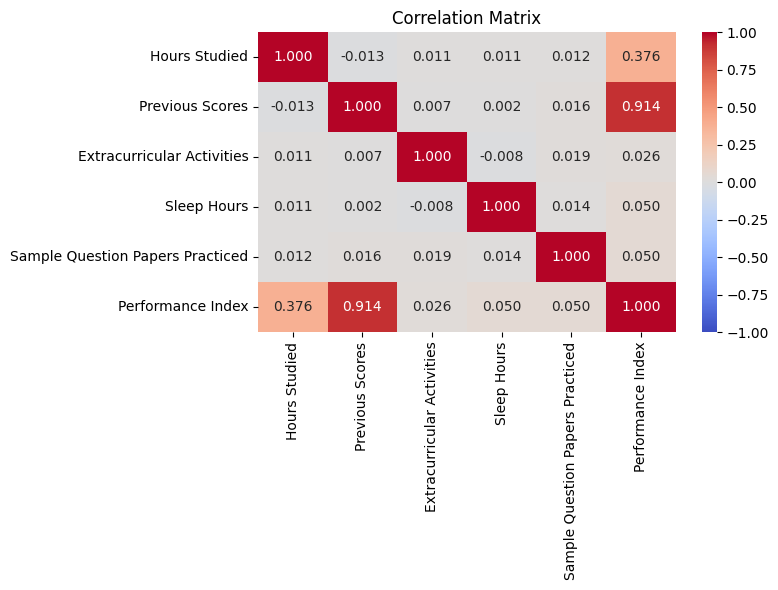

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = clean_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()

### 3-3. 주요 설명변수와 목표변수의 관계

목표변수인 `Performance Index`와 `Previous Scores` 의 연관 관계를 산점도로 출력하고,  
목표변수인 `Performance Index`와 `Extracurricular Activitie` 의 연관 관계를 박스 플롯으로 출력합니다.

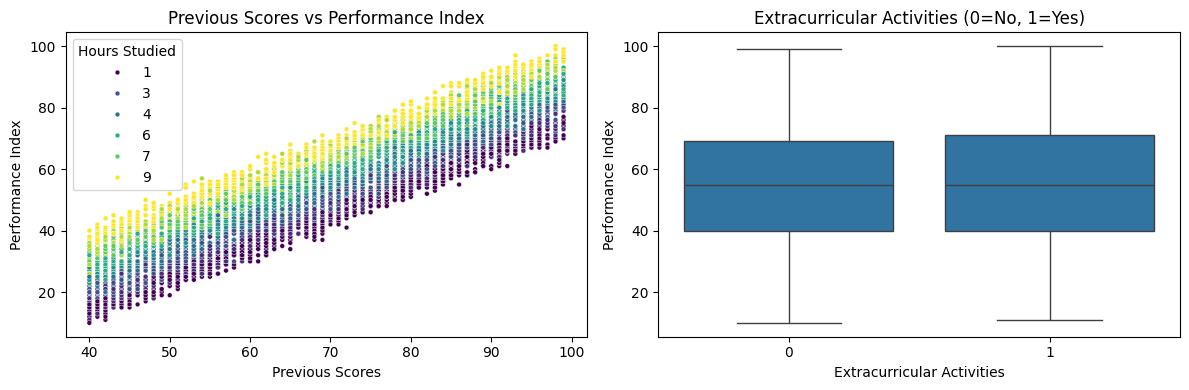

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(
    data=clean_df, x="Previous Scores", y=TARGET_COLUMN,
    hue="Hours Studied", palette="viridis", s=12, ax=axes[0],
)
axes[0].set_title("Previous Scores vs Performance Index")

sns.boxplot(
    data=clean_df, x=CATEGORICAL_COLUMN, y=TARGET_COLUMN, ax=axes[1],
)
axes[1].set_title("Extracurricular Activities (0=No, 1=Yes)")
plt.tight_layout()
plt.show()

### EDA 요약

- 목표변수(Performance Index)는 10~100 범위에서 완만한 종 모양 분포를 보입니다.
- **Previous Scores(상관, 약 0.92)** 와 **Hours Studied(상관, 약 0.37)** 가  
  지배적 설명변수로 확인됩니다.
- Previous Scores–Performance Index 산점도에서 Hours Studied에 따라 층이 나뉘는
  **뚜렷한 선형 구조**가 관찰됩니다 : 선형 회귀 계열이 적합한 문제
- 수면 시간, 모의고사 수, 과외 활동과의 상관은 그렇게 크지 않습니다.

## 4. 회귀 모델링

표준화 + 회귀 모델을 하나의 `Pipeline`으로 묶어 학습합니다.  
검증 데이터(20%)에 대한 **RMSE**와 **R2 Score**로 성능을 평가한뒤에,  
LinearRegression과 Ridge를 비교하겠습니다.

In [10]:
feature_columns = [c for c in clean_df.columns if c != TARGET_COLUMN]
X = clean_df[feature_columns]
y = clean_df[TARGET_COLUMN]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED,
)
print(f"train: {X_train.shape}, valid: {X_valid.shape}")

train: (5548, 5), valid: (1388, 5)


In [11]:
def build_pipeline(regressor) -> Pipeline:
    """Standardize features then fit the given regressor."""
    return Pipeline([
        ("scaler", StandardScaler()),
        ("regressor", regressor),
    ])


candidates = {
    "LinearRegression": build_pipeline(LinearRegression()),
    "Ridge(alpha=1.0)": build_pipeline(Ridge(alpha=1.0, random_state=RANDOM_SEED)),
}

results = {}
for name, pipeline in candidates.items():
    pipeline.fit(X_train, y_train)
    pred = pipeline.predict(X_valid)
    rmse = float(np.sqrt(mean_squared_error(y_valid, pred)))
    r2 = float(r2_score(y_valid, pred))
    results[name] = {"RMSE": rmse, "R2": r2}

results_df = pd.DataFrame(results).T.sort_values("RMSE")
print(results_df.round(4))

                    RMSE     R2
LinearRegression  2.0375  0.989
Ridge(alpha=1.0)  2.0376  0.989


### 모델 선택

두 모델의 성능이 사실상 동일하므로(강한 선형 구조),  
가장 단순한 **LinearRegression**을 최종 모델로 선택합니다.  
회귀 계수로 각 변수의 기여도(coefficient)를 확인하겠습니다.

In [12]:
best_name = results_df.index[0]
best_pipeline = candidates[best_name]
print(f"selected model: {best_name}")

coef_df = pd.DataFrame({
    "feature": feature_columns,
    "coefficient": best_pipeline.named_steps["regressor"].coef_,
}).sort_values("coefficient", key=abs, ascending=False)
print(coef_df.round(4))

selected model: LinearRegression
                            feature  coefficient
1                   Previous Scores      17.5052
0                     Hours Studied       7.4265
3                       Sleep Hours       0.8113
4  Sample Question Papers Practiced       0.5580
2        Extracurricular Activities       0.3045


## 5. 최종 모델 학습 및 저장

검증을 마쳤으므로 **전체 학습 데이터로 재학습**한 뒤 `output/model.pkl`로 저장하겠습니다.  
전처리(표준화)가 파이프라인에 포함되어 있어,  
연구자 2는 원본 스케일의 입력으로 바로 추론이 가능합니다.  
모델이 생성되면 모델 검증에서 사용했던 X_valid 의 5개 샘플을 모델에 주입하여,  
notebook의 실제 정답인 y_valid와 비교하여 타당성을 검토합니다.

In [13]:
import os

MODEL_OUTPUT_DIR = "output"
MODEL_FILENAME = "model.pkl"

final_pipeline = build_pipeline(LinearRegression())
final_pipeline.fit(X, y)

os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)
model_path = os.path.join(MODEL_OUTPUT_DIR, MODEL_FILENAME)
joblib.dump(final_pipeline, model_path)
print(f"model saved: {model_path} ({os.path.getsize(model_path)} bytes)")

model saved: output/model.pkl (1606 bytes)


In [14]:
# Sanity check: reload and predict on a held-out sample
reloaded = joblib.load(model_path)
sample = X_valid.head(5)
comparison = pd.DataFrame({
    "actual": y_valid.head(5).to_numpy(),
    "predicted": reloaded.predict(sample).round(2),
})
print(comparison)

   actual  predicted
0    59.0      61.80
1    58.0      60.08
2    59.0      59.13
3    67.0      68.92
4    53.0      54.92


타당성 검사 결과, 모델의 예측오차(잔차) 범위(≈2) 이내로 문제 없습니다.

## 6. 결과 요약

- 전처리: Yes/No 이진 인코딩 + 중복 제거 + 표준화(파이프라인 내장)
- 최종 모델: `StandardScaler + LinearRegression` 파이프라인
- 검증 RMSE ≈ 2.0 수준 (목표변수 범위 10~100 대비 매우 양호)
- 산출물: `output/model.pkl`